# Brain-to-Text Metrics v2

This notebook evaluates NeuroVLM brain-to-text generation separately from text-to-brain. It keeps the semantic metrics from `new_neuropvlm_metrics_v2`, removes the cleaned abstract branch, adds Recall@1 retrieval, and adds network label accuracy for the Networks test set.

This notebook is configured to run the full available networks, PubMed test, and NeuroVault evaluation sets by default. For fast iteration, set `MAX_B2T` to a small integer.

In [1]:
import os
import hashlib
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset, load_latent
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer, util as st_util
from transformers import AutoModel, AutoTokenizer


In [2]:
LLM_BACKEND = "huggingface"
LLM_MODEL = "qwen2.5:7b-instruct"
BERTSCORE_MODEL = "microsoft/deberta-xlarge-mnli"
MINILM_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
MPNET_MODEL = "sentence-transformers/all-mpnet-base-v2"
B2T_RANDOM_EVIDENCE_N_SAMPLES = 25
B2T_RANDOM_EVIDENCE_SEED = 13

MAX_B2T = None        # full available networks, PubMed test, and NeuroVault sets
RUN_NETWORKS = True
RUN_PUBMED = True
RUN_NEUROVAULT = True
RUN_GENERATED_TEXT = False  # slow LLM/BERTScore generated-text evaluation

B2T_TOP_K = 5
B2T_SIM_THR = 0.35
B2T_DATASETS = ["llm_neuro_terms", "pubmed_mesh", "cogatlas"]
from neurovlm.evaluation_notebook_utils import resolve_evaluation_output_dir

OUTPUT_DIR = resolve_evaluation_output_dir()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
nvlm = NeuroVLM()
B2T_ENCODER_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
_st_model = SentenceTransformer(MINILM_MODEL, device=B2T_ENCODER_DEVICE)
_mpnet_model = SentenceTransformer(MPNET_MODEL, device=B2T_ENCODER_DEVICE)
print(f"Ready. Sentence encoders on {B2T_ENCODER_DEVICE}.")


Ready. Sentence encoders on cpu.


In [4]:
from neurovlm.evaluation_notebook_utils import load_network_label_resources

network_labels_df, network_info, NETWORK_TEST_SET_SOURCE = load_network_label_resources()

DISPLAY_TO_KEY = dict(zip(network_info["display"], network_info["network_key"]))
KEY_TO_DISPLAY = dict(zip(network_info["network_key"], network_info["display"]))
SHORT_LABELS = dict(zip(network_info["display"], network_info["short_definition"]))
LONG_LABELS = dict(zip(network_info["display"], network_info["long_definition"]))

print(f"Loaded {len(network_info)} canonical network labels from {NETWORK_TEST_SET_SOURCE}")
display(network_info[["network_key", "display", "short_definition"]])


Loaded 8 canonical network labels from huggingface:neurovlm/embedded_text/network_test_set_labels.csv


,network_key,display,short_definition
0,attention,Attention,Dorsal attention network for selective attenti...
1,auditory,Auditory,"Auditory network for auditory perception, soun..."
2,cingulo_opercular,Cingulo-Opercular,Cingulo-opercular/salience network for salienc...
3,default_mode,Default Mode,Default mode network for self-referential thou...
4,frontoparietal_control,Frontoparietal Control,Frontoparietal control network for executive c...
5,language,Language,"Language network for speech comprehension, spe..."
6,motor,Motor,"Sensorimotor network for movement planning, vo..."
7,visual,Visual,"Visual network for visual perception, object r..."


In [5]:
from neurovlm.evaluation_notebook_utils import build_labeled_network_data

networks_data, all_net_latents = build_labeled_network_data(network_labels_df)

print(f"Networks loaded: {len(networks_data)} labeled maps across {len(all_net_latents)} atlases")
display(pd.DataFrame([
    {"sample": name, "network_key": d["network_key"], "display": d["display"]}
    for name, d in networks_data.items()
]).head())


Networks loaded: 119 labeled maps across 10 atlases


,sample,network_key,display
0,Du:CG-OP,cingulo_opercular,Cingulo-Opercular
1,Du:DN-B,default_mode,Default Mode
2,Du:SMOT-B,motor,Motor
3,Du:AUD,auditory,Auditory
4,Du:PM-PPr,motor,Motor


In [6]:
from neurovlm.evaluation_notebook_utils import build_pubmed_b2t_eval

pubmed_eval, pubmed_stats = build_pubmed_b2t_eval(MAX_B2T)
if pubmed_stats["missing_summary_latents"]:
    print(f"Skipped {pubmed_stats['missing_summary_latents']:,} PubMed test papers without precomputed summary text latents.")
print(f"PubMed summary test samples: {pubmed_stats['eval_records']} / {pubmed_stats['records']}")
print(f"Summaries table rows: {pubmed_stats['summary_rows']:,}; test rows: {pubmed_stats['test_rows']:,}")


PubMed summary test samples: 2987 / 2987
Summaries table rows: 30,826; test rows: 3,945


In [7]:
from neurovlm.evaluation_notebook_utils import build_neurovault_b2t_eval

neurovault_eval, neurovault_selection_df = build_neurovault_b2t_eval(nvlm, OUTPUT_DIR, MAX_B2T)
print(f"NeuroVault samples: {len(neurovault_eval)} / {len(neurovault_selection_df)}")
print("NeuroVault image selection: argmax brain-image/shared-text similarity per DOI.")


NeuroVault samples: 312 / 312
NeuroVault image selection: argmax brain-image/shared-text similarity per DOI.


## Metric Helpers

`nvlm_sim` is a cosine similarity in NeuroVLM's shared latent space. A value around 0.33 can be meaningful because it is measured against a broad retrieval space, so the notebook plots it with empirical quartiles and a random-pair baseline rather than treating 1.0 as the only intuitive target.

In [8]:
from neurovlm.brain_to_text_metrics import make_b2t_runner

SHORT_PROMPT_GENERAL = (
    "Reply with a single concise sentence (10-20 words) naming the main cognitive "
    "function or brain network. Output only that sentence."
)
SHORT_PROMPT_PUBMED = (
    "Generate only a paper title (6-12 words) for the neuroimaging study this "
    "brain activation pattern represents. Output the title only."
)
LONG_PROMPT = ""

run_b2t = make_b2t_runner(
    nvlm=nvlm,
    st_model=_st_model,
    st_util=st_util,
    bert_score_fn=bert_score,
    bertscore_model=BERTSCORE_MODEL,
    llm_backend=LLM_BACKEND,
    llm_model=LLM_MODEL,
    b2t_datasets=B2T_DATASETS,
    b2t_top_k=B2T_TOP_K,
    b2t_sim_threshold=B2T_SIM_THR,
)


In [9]:
from neurovlm.brain_to_text_metrics import make_network_label_accuracy_adder

add_network_label_accuracy = make_network_label_accuracy_adder(
    networks_data=networks_data,
    network_info=network_info,
    st_model=_st_model,
    st_util=st_util,
)


## Retrieval Evidence Metrics

These analyses evaluate retrieval before any LLM generation. That keeps the metric tied to what the brain encoder ranks, rather than to how well the LLM writes from those ranked results.

- **Paper-level retrieval** is the canonical PubMed metric and is also applied to NeuroVault. It asks whether each brain embedding retrieves its paired paper text, with exact-paper and semantic-neighbor variants.
- **Network gold-term ranking** asks whether known network terms appear high in the ranked NeuroVLM term list. The notebook keeps the broad `llm_neuro_terms + pubmed_mesh + cogatlas` corpus; normalized k keeps this comparable to a network-CSV-only term corpus.

Generated text evaluation is kept later and is disabled by default because it is much slower.


### PubMed Retrieval Corpus

PubMed paper-level retrieval is the primary PubMed metric. This setting only controls the MeSH corpus used later if generated-text context is retrieved for PubMed examples.


In [10]:
INCLUDE_MOLECULAR_MESH = False
MESH_BRAIN_RANKABLE_NODE_TYPES = [
    "disorder",
    "anatomical_region",
    "biological_process",
    "cognitive_construct",
]
if INCLUDE_MOLECULAR_MESH:
    MESH_BRAIN_RANKABLE_NODE_TYPES.append("molecular")

PUBMED_B2T_DATASET = "pubmed_mesh_brain_rankable_plus_molecular" if INCLUDE_MOLECULAR_MESH else "pubmed_mesh_brain_rankable"
print(f"PubMed generated-text retrieval corpus: {PUBMED_B2T_DATASET}")
print(f"Allowed PubMed MeSH node types in that corpus: {MESH_BRAIN_RANKABLE_NODE_TYPES}")


PubMed generated-text retrieval corpus: pubmed_mesh_brain_rankable
Allowed PubMed MeSH node types in that corpus: ['disorder', 'anatomical_region', 'biological_process', 'cognitive_construct']


In [11]:
from neurovlm.brain_to_text_metrics import (
    dataset_records_for_retrieval_eval,
    full_retrieval_table_for_sample,
    network_gold_terms,
    normalize_term_text,
    pubmed_abstract_lookup,
    terms_for_dataset,
    unique_ranked_terms_from_table,
)

TERM_EVAL_NORMALIZED_KS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
TERM_RECALL_CURVE_NORMALIZED_KS = np.linspace(0.0, 1.0, 101)
B2T_TERM_EXAMPLE_TOP_K = 20
B2T_TERM_TOP_K = B2T_TERM_EXAMPLE_TOP_K
B2T_EVIDENCE_TOP_K = B2T_TOP_K
NETWORK_B2T_TERM_DATASETS = ["llm_neuro_terms", "pubmed_mesh", "cogatlas"]
B2T_TERM_DATASETS_BY_EVAL_DATASET = {
    "networks": NETWORK_B2T_TERM_DATASETS,
    "pubmed": [PUBMED_B2T_DATASET],
    "neurovault": NETWORK_B2T_TERM_DATASETS,
}
B2T_RETRIEVAL_TABLE_CACHE = {}
PUBMED_ABSTRACT_LOOKUP = pubmed_abstract_lookup()


### Paper-Level Retrieval: PubMed and NeuroVault

This is the canonical retrieval metric for PubMed papers and is also applied to NeuroVault. It asks whether each brain embedding retrieves its paired paper text from the held-out candidate set, before any LLM generation.

The paper text embeddings come from the precomputed Hugging Face latent files (`pubmed_summaries` and `neurovault_text`), then use the NeuroVLM text projection head. They are not re-encoded in the notebook. For NeuroVault, the representative brain map for each DOI is selected by argmax similarity between candidate image embeddings and the paired publication text embedding.

Metric columns:

- `brain_to_paper_normalized_k_recall_curve_auc`: strict exact-pair retrieval from brain embeddings to paper text embeddings, integrated over `k / n_papers`.
- `paper_to_brain_normalized_k_recall_curve_auc`: reverse exact-pair retrieval from paper text embeddings to brain embeddings.
- `semantic_normalized_k_recall_curve_auc`: paper retrieval where the exact paper and its nearest text neighbors count as positives; this is less brittle than exact PMID/DOI matching.


In [12]:
from neurovlm.brain_to_text_metrics import run_paper_retrieval_evaluations

PAPER_RETRIEVAL_BRAIN_BATCH_SIZE = 512
PAPER_RETRIEVAL_TEXT_BATCH_SIZE = 512
PAPER_RETRIEVAL_SEMANTIC_NEIGHBORS = 10

b2t_paper_retrieval_metrics_df, b2t_paper_retrieval_curves_df, b2t_paper_retrieval_examples_df = run_paper_retrieval_evaluations(
    nvlm=nvlm,
    pubmed_eval=pubmed_eval,
    neurovault_eval=neurovault_eval,
    output_dir=OUTPUT_DIR,
    run_pubmed=RUN_PUBMED,
    run_neurovault=RUN_NEUROVAULT,
    semantic_neighbors=PAPER_RETRIEVAL_SEMANTIC_NEIGHBORS,
    brain_batch_size=PAPER_RETRIEVAL_BRAIN_BATCH_SIZE,
    text_batch_size=PAPER_RETRIEVAL_TEXT_BATCH_SIZE,
)

if len(b2t_paper_retrieval_metrics_df):
    display(b2t_paper_retrieval_metrics_df.round(3))
else:
    print("No PubMed/NeuroVault paper retrieval metrics were computed.")


,dataset,n_papers,brain_to_paper_normalized_k_recall_curve_auc,paper_to_brain_normalized_k_recall_curve_auc,semantic_normalized_k_recall_curve_auc
0,pubmed,2987,0.833,0.834,0.925
1,neurovault,312,0.856,0.854,0.949


### Paper Retrieval Visualization

Each dataset gets its own plot with three recall curves: strict brain-to-paper retrieval, strict paper-to-brain retrieval, and semantic-neighbor brain-to-paper retrieval. The legend reports normalized-k recall-curve AUC for each curve. Curves above the dashed diagonal retrieve relevant papers earlier than random ranking.


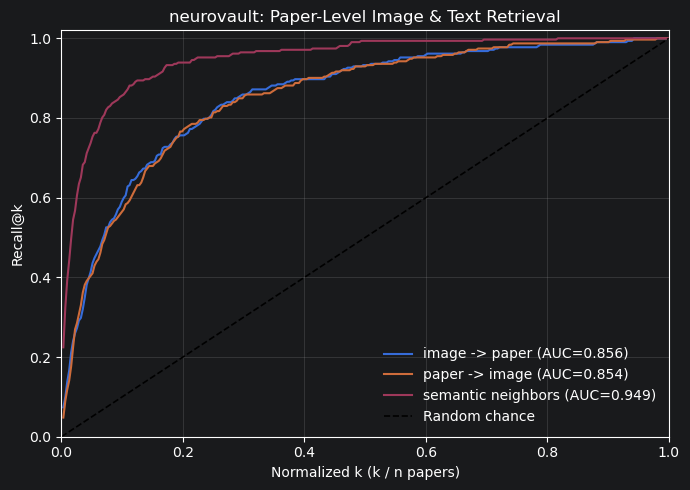

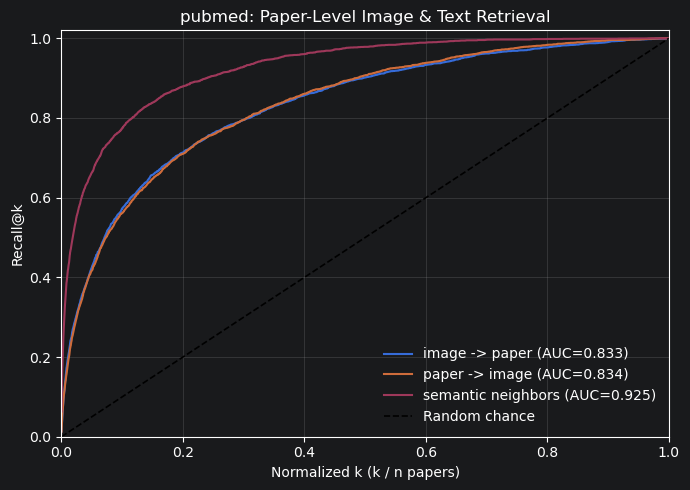

In [13]:
if len(b2t_paper_retrieval_curves_df):
    metric_labels = [
        ("brain_to_paper_recall_curve", "image -> paper", "brain_to_paper_normalized_k_recall_curve_auc"),
        ("paper_to_brain_recall_curve", "paper -> image", "paper_to_brain_normalized_k_recall_curve_auc"),
        ("semantic_recall_curve", "semantic neighbors", "semantic_normalized_k_recall_curve_auc"),
    ]

    for dataset, sub in b2t_paper_retrieval_curves_df.groupby("dataset"):
        metrics_row = b2t_paper_retrieval_metrics_df.set_index("dataset").loc[dataset]
        fig, ax = plt.subplots(figsize=(7, 5))

        for curve_col, label, auc_col in metric_labels:
            auc = float(metrics_row[auc_col])
            ax.plot(
                sub["normalized_k"],
                sub[curve_col],
                label=f"{label} (AUC={auc:.3f})",
            )

        ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
        ax.set_xlabel("Normalized k (k / n papers)")
        ax.set_ylabel("Recall@k")
        ax.set_title(f"{dataset}: Paper-Level Image & Text Retrieval")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.grid(alpha=0.25)
        ax.legend(frameon=False)
        fig.tight_layout()

        plt.savefig(
            OUTPUT_DIR / f"b2t_paper_retrieval_curves_{dataset}.png",
            dpi=150,
            bbox_inches="tight",
        )
        plt.show()
else:
    print("No paper retrieval curves to plot.")

### Network Gold-Term Ranking

This evaluates whether the full ranked NeuroVLM term list retrieves known network terms from the network test-set CSV. The candidate corpus is intentionally broad (`llm_neuro_terms`, `pubmed_mesh`, and `cogatlas`), while the gold terms come from the CSV. A CSV-term-only candidate corpus should lead to the same interpretation when results are reported against normalized k; this broader corpus is the stricter retrieval setting.

Metric columns:

- `normalized_k_target`: the requested fraction of the candidate corpus to inspect, such as `0.01` for the top 1%.
- `k`: the actual number of retrieved terms inspected, computed as `ceil(normalized_k_target * n_candidate_terms)`.
- `n_candidate_terms`: the number of unique terms the model could rank after normalizing/deduplicating term names.
- `n_gold_terms`: gold terms that are reachable in the candidate corpus. Unreachable terms are excluded so the model is not penalized for terms it could never retrieve.
- `n_unreachable_gold_terms`: gold terms missing from the retrieval corpora; this is a fairness/audit check.
- `precision_at_normalized_k`: among the inspected top-k terms, the fraction that are gold terms.
- `recall_at_normalized_k`: among the reachable gold terms, the fraction recovered within the inspected top-k terms.
- `hit_at_normalized_k`: whether at least one gold term appears in the inspected top-k terms.
- `mrr_at_normalized_k`: reciprocal rank of the first gold-term hit if it appears within top-k.
- `normalized_first_hit_rank`: first gold-term rank divided by `n_candidate_terms`; lower is better and accounts for corpus size.
- `expected_random_recall_at_normalized_k`: chance-level recall if terms were randomly ordered.
- `recall_auc`: area under the recall-vs-normalized-k curve. Higher means gold terms appear earlier across the full ranked list.

The recall curve plots `recall_at_normalized_k` on the y-axis and normalized k on the x-axis. A curve above the diagonal means the brain-to-text retrieval ranks gold terms earlier than random chance.


In [14]:
from neurovlm.brain_to_text_metrics import exact_term_ranking_outputs

network_candidate_terms = set().union(*(terms_for_dataset(ds) for ds in NETWORK_B2T_TERM_DATASETS))
network_missing_rows = []
for sample_name in networks_data:
    for term in network_gold_terms(sample_name, networks_data, network_labels_df):
        norm = normalize_term_text(term)
        if norm and norm not in network_candidate_terms:
            network_missing_rows.append({"sample": sample_name, "term": term, "normalized_term": norm})
network_missing_terms_df = pd.DataFrame(network_missing_rows).drop_duplicates() if network_missing_rows else pd.DataFrame(columns=["sample", "term", "normalized_term"])
display(network_missing_terms_df.head(25))
print(f"Network gold terms missing from llm_neuro_terms + pubmed_mesh + cogatlas: {len(network_missing_terms_df):,}")
if len(network_missing_terms_df):
    network_missing_terms_df.to_csv(OUTPUT_DIR / "network_gold_terms_missing_from_retrieval_corpora.csv", index=False)

pubmed_candidate_terms = terms_for_dataset(PUBMED_B2T_DATASET)


,sample,term,normalized_term


Network gold terms missing from llm_neuro_terms + pubmed_mesh + cogatlas: 0


In [15]:
from neurovlm.brain_to_text_metrics import run_network_gold_term_ranking

b2t_term_metrics_df, b2t_term_recall_curve_df, b2t_term_auc_df, b2t_term_examples_df = run_network_gold_term_ranking(
    nvlm=nvlm,
    networks_data=networks_data,
    network_labels_df=network_labels_df,
    pubmed_eval=pubmed_eval,
    neurovault_eval=neurovault_eval,
    pubmed_abs_lookup=PUBMED_ABSTRACT_LOOKUP,
    network_candidate_terms=network_candidate_terms,
    term_datasets_by_eval_dataset=B2T_TERM_DATASETS_BY_EVAL_DATASET,
    retrieval_table_cache=B2T_RETRIEVAL_TABLE_CACHE,
    term_eval_normalized_ks=TERM_EVAL_NORMALIZED_KS,
    term_recall_curve_normalized_ks=TERM_RECALL_CURVE_NORMALIZED_KS,
    b2t_term_example_top_k=B2T_TERM_EXAMPLE_TOP_K,
    output_dir=OUTPUT_DIR,
    run_networks=RUN_NETWORKS,
    run_pubmed=RUN_PUBMED,
    run_neurovault=RUN_NEUROVAULT,
)

if len(b2t_term_metrics_df):
    display(
        b2t_term_metrics_df
        .groupby(["dataset", "normalized_k_target"])[
            [
                "normalized_k", "k", "n_candidate_terms",
                "precision_at_normalized_k", "recall_at_normalized_k",
                "hit_at_normalized_k", "mrr_at_normalized_k",
                "expected_random_recall_at_normalized_k", "n_unreachable_gold_terms",
            ]
        ]
        .mean()
        .round(3)
    )
    display(b2t_term_auc_df.groupby("dataset")[["recall_auc", "expected_random_recall_auc", "recall_auc_minus_random"]].agg(["mean", "std", "count"]).round(3))
else:
    print("No network gold-term metrics were computed.")


Network normalized gold-term ranking:   0%|          | 0/3418 [00:00<?, ?it/s]

normalized_k       k  n_candidate_terms  \
dataset  normalized_k_target                                            
networks 0.001                       0.001    36.0            35896.0   
         0.005                       0.005   180.0            35896.0   
         0.010                       0.010   359.0            35896.0   
         0.020                       0.020   718.0            35896.0   
         0.050                       0.050  1795.0            35896.0   
         0.100                       0.100  3590.0            35896.0   

                              precision_at_normalized_k  \
dataset  normalized_k_target                              
networks 0.001                                    0.110   
         0.005                                    0.049   
         0.010                                    0.031   
         0.020                                    0.018   
         0.050                                    0.008   
         0.100                                    0.004   

                              recall_at_normalized_k  hit_at_normalized_k  \
dataset  normalized_k_target                                                
networks 0.001                                 0.186                0.798   
         0.005                                 0.422                0.908   
         0.010                                 0.538                0.950   
         0.020                                 0.635                0.983   
         0.050                                 0.732                1.000   
         0.100                                 0.786                1.000   

                              mrr_at_normalized_k  \
dataset  normalized_k_target                        
networks 0.001                              0.236   
         0.005                              0.238   
         0.010                              0.238   
         0.020                              0.238   
         0.050                              0.238   
         0.100                              0.238   

                              expected_random_recall_at_normalized_k  \
dataset  normalized_k_target                                           
networks 0.001                                                 0.001   
         0.005                                                 0.005   
         0.010                                                 0.010   
         0.020                                                 0.020   
         0.050                                                 0.050   
         0.100                                                 0.100   

                              n_unreachable_gold_terms  
dataset  normalized_k_target                            
networks 0.001                                   1.151  
         0.005                                   1.151  
         0.010                                   1.151  
         0.020                                   1.151  
         0.050                                   1.151  
         0.100                                   1.151

recall_auc              expected_random_recall_auc             \
               mean    std count                       mean  std count   
dataset                                                                  
networks      0.881  0.155   119                        0.5  0.0   119   

         recall_auc_minus_random               
                            mean    std count  
dataset                                        
networks                   0.381  0.155   119

### Network Term-Ranking Visualization

This plot shows how quickly known network gold terms appear as the normalized term budget grows. Because the x-axis is `k / n_candidate_terms`, the curve remains interpretable even when comparing the broad NeuroVLM corpus with a smaller CSV-term-only corpus.


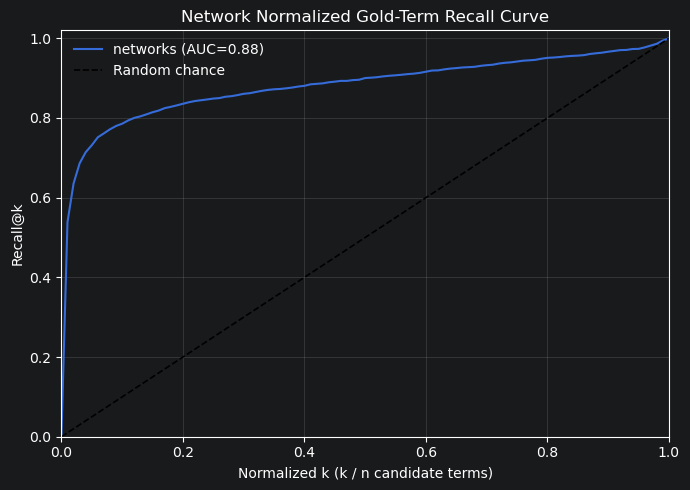

In [16]:
if len(b2t_term_recall_curve_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    curve_summary = (
        b2t_term_recall_curve_df
        .groupby(["dataset", "normalized_k_target"])
        .agg(recall_mean=("recall_at_normalized_k", "mean"), recall_std=("recall_at_normalized_k", "std"), n=("sample", "count"))
        .reset_index()
    )
    auc_means = b2t_term_auc_df.groupby("dataset")["recall_auc"].mean().to_dict()
    for dataset, sub in curve_summary.groupby("dataset"):
        label = f"{dataset} (AUC={auc_means.get(dataset, np.nan):.2f})"
        ax.plot(sub["normalized_k_target"], sub["recall_mean"], label=label)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
    ax.set_xlabel("Normalized k (k / n candidate terms)")
    ax.set_ylabel("Recall@k")
    ax.set_title("Network Normalized Gold-Term Recall Curve")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_approach1_normalized_recall_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No recall curve rows to plot.")


In [17]:
from neurovlm.brain_to_text_metrics import predownload_hf_model

if RUN_GENERATED_TEXT:
    predownload_hf_model(BERTSCORE_MODEL, AutoTokenizer, AutoModel)
else:
    print("Skipping BERTScore model pre-download because RUN_GENERATED_TEXT = False.")


Skipping BERTScore model pre-download because RUN_GENERATED_TEXT = False.


### PubMed MeSH Candidate Corpus Filtering

This diagnostic cell reports the MeSH candidate counts for the full MeSH corpus, the neuro-tree-filtered descriptor set from `mesh_kg.ipynb`, and the final node-type candidate set used by the recall curves. The neuro-tree filter uses MeSH tree prefixes `A08`, `C10`, `C23`, `D02`, `D12`, `F01`, `F02`, and `F03`, matching the `NEURO_TREE_PREFIXES` logic in the MeSH KG notebook.

An optional top-k-discovered filter can be enabled after the neuro-tree filter. That diagnostic can reduce non-neuroscience noise further, but it is model- and evaluation-set-dependent and should be reported as a filtered-corpus diagnostic rather than an unbiased primary metric.


In [18]:
from neurovlm.brain_to_text_metrics import mesh_descriptor_name, project_brain_latents_to_shared, project_text_latents_to_shared

USE_MESH_NEURO_TREE_FILTER = True
MESH_NEURO_TREE_PREFIXES = {"A08", "C10", "C23", "D02", "D12", "F01", "F02", "F03"}
USE_TOPK_MESH_CANDIDATE_FILTER = True  # Set True for the mentor-suggested filtered-corpus diagnostic.
MESH_TOPK_DISCOVERY_K = 50
MESH_TOPK_DISCOVERY_MIN_QUERY_HITS = 1

mesh_full_df = load_dataset("pubmed_mesh").copy()
mesh_rankable_df = load_dataset(PUBMED_B2T_DATASET).copy()
mesh_nodes_filter_df = load_dataset("pubmed_mesh_nodes").copy()
mesh_descriptors_filter_df = load_dataset("pubmed_mesh_descriptors").copy()
mesh_rankable_latents, _mesh_rankable_terms = load_latent(PUBMED_B2T_DATASET)

mesh_full_term_col = next((col for col in ["term", "title", "name", "label"] if col in mesh_full_df.columns), None)
mesh_rankable_term_col = next((col for col in ["term", "title", "name", "label"] if col in mesh_rankable_df.columns), None)
mesh_node_name_col = "name" if "name" in mesh_nodes_filter_df.columns else "term"
if mesh_full_term_col is None or mesh_rankable_term_col is None:
    raise KeyError("MeSH dataframes must contain one of term/title/name/label columns.")

mesh_node_type_by_norm = {
    normalize_term_text(row[mesh_node_name_col]): row["node_type"]
    for _, row in mesh_nodes_filter_df.iterrows()
    if pd.notna(row.get(mesh_node_name_col)) and pd.notna(row.get("node_type"))
}
mesh_full_df["term"] = mesh_full_df[mesh_full_term_col].astype(str).map(mesh_descriptor_name)
mesh_full_df["normalized_term"] = mesh_full_df["term"].map(normalize_term_text)
mesh_rankable_df["term"] = mesh_rankable_df[mesh_rankable_term_col].astype(str).map(mesh_descriptor_name)
mesh_rankable_df["normalized_term"] = mesh_rankable_df["term"].map(normalize_term_text)
mesh_rankable_df["node_type"] = mesh_rankable_df["normalized_term"].map(mesh_node_type_by_norm).fillna("")

mesh_descriptors_filter_df["normalized_term"] = mesh_descriptors_filter_df["name"].astype(str).map(normalize_term_text)
mesh_descriptors_filter_df["neuro_tree_relevant"] = mesh_descriptors_filter_df["tree_numbers"].apply(
    lambda tns: any(str(tn).split(".")[0][:3] in MESH_NEURO_TREE_PREFIXES for tn in tns)
)
MESH_NEURO_TREE_DESCRIPTOR_COUNT = int(mesh_descriptors_filter_df["neuro_tree_relevant"].sum())
MESH_NEURO_TREE_NORMALIZED_TERMS = set(
    mesh_descriptors_filter_df.loc[mesh_descriptors_filter_df["neuro_tree_relevant"], "normalized_term"].astype(str)
)

node_type_mask = mesh_rankable_df["node_type"].isin(MESH_BRAIN_RANKABLE_NODE_TYPES)
if USE_MESH_NEURO_TREE_FILTER:
    neuro_tree_mask = mesh_rankable_df["normalized_term"].isin(MESH_NEURO_TREE_NORMALIZED_TERMS)
else:
    neuro_tree_mask = np.ones(len(mesh_rankable_df), dtype=bool)
keep_mask = (node_type_mask & neuro_tree_mask).to_numpy() if hasattr(node_type_mask, "to_numpy") else node_type_mask & neuro_tree_mask
mesh_rankable_df = mesh_rankable_df.loc[keep_mask].copy()
mesh_rankable_latents = mesh_rankable_latents[keep_mask]
unique_rankable_mask = ~mesh_rankable_df["normalized_term"].duplicated(keep="first").to_numpy()
mesh_rankable_df = mesh_rankable_df.loc[unique_rankable_mask].reset_index(drop=True)
mesh_rankable_latents = mesh_rankable_latents[unique_rankable_mask]

mesh_candidate_filter_counts_df = pd.DataFrame([
    {"stage": "full_pubmed_mesh", "n_terms": int(mesh_full_df["normalized_term"].nunique())},
    {"stage": "neuro_tree_descriptors", "n_terms": MESH_NEURO_TREE_DESCRIPTOR_COUNT},
    {"stage": "node_type_only", "n_terms": int(load_dataset(PUBMED_B2T_DATASET).shape[0])},
    {"stage": "neuro_tree_and_selected_node_types", "n_terms": int(mesh_rankable_df["normalized_term"].nunique())},
])
mesh_node_type_filter_counts_df = (
    mesh_rankable_df.groupby("node_type")
    .size()
    .reindex(MESH_BRAIN_RANKABLE_NODE_TYPES)
    .fillna(0)
    .astype(int)
    .rename("n_candidate_terms")
    .reset_index()
)
display(mesh_candidate_filter_counts_df)
display(mesh_node_type_filter_counts_df)

MESH_CANDIDATE_NORMALIZED_TERMS = set(mesh_rankable_df["normalized_term"].astype(str)) if USE_MESH_NEURO_TREE_FILTER else None
mesh_topk_discovery_counts_df = pd.DataFrame()
if USE_TOPK_MESH_CANDIDATE_FILTER and RUN_PUBMED and len(pubmed_eval):
    mesh_brain_embeddings_for_filter = project_brain_latents_to_shared(nvlm, [d["latent"] for d in pubmed_eval])
    mesh_candidate_embeddings_for_filter = project_text_latents_to_shared(nvlm, mesh_rankable_latents)
    mesh_filter_scores = mesh_brain_embeddings_for_filter @ mesh_candidate_embeddings_for_filter.T
    discovery_k = min(MESH_TOPK_DISCOVERY_K, mesh_filter_scores.shape[1])
    topk_indices = torch.topk(mesh_filter_scores, k=discovery_k, dim=1).indices.cpu().numpy()
    hit_counts = np.bincount(topk_indices.reshape(-1), minlength=len(mesh_rankable_df))
    mesh_rankable_df["topk_query_hits"] = hit_counts
    mesh_topk_filter_df = mesh_rankable_df[mesh_rankable_df["topk_query_hits"] >= MESH_TOPK_DISCOVERY_MIN_QUERY_HITS].copy()
    MESH_CANDIDATE_NORMALIZED_TERMS = set(mesh_topk_filter_df["normalized_term"].astype(str))
    mesh_topk_discovery_counts_df = (
        mesh_topk_filter_df.groupby("node_type")
        .size()
        .reindex(MESH_BRAIN_RANKABLE_NODE_TYPES)
        .fillna(0)
        .astype(int)
        .rename("n_topk_discovered_terms")
        .reset_index()
    )
    display(mesh_topk_discovery_counts_df)
    mesh_topk_filter_df.to_csv(OUTPUT_DIR / "b2t_pubmed_mesh_topk_discovered_candidate_terms.csv", index=False)
    print(f"Using neuro-tree + top-k-discovered MeSH candidate filter: {len(MESH_CANDIDATE_NORMALIZED_TERMS):,} terms kept with k={discovery_k} and min_query_hits={MESH_TOPK_DISCOVERY_MIN_QUERY_HITS}.")
    print("Saved filtered candidate terms to", OUTPUT_DIR / "b2t_pubmed_mesh_topk_discovered_candidate_terms.csv")
elif USE_MESH_NEURO_TREE_FILTER:
    print(f"Using neuro-tree-filtered MeSH candidate corpus: {len(MESH_CANDIDATE_NORMALIZED_TERMS):,} selected-node-type terms kept from {MESH_NEURO_TREE_DESCRIPTOR_COUNT:,} neuro-tree descriptors ({len(MESH_NEURO_TREE_NORMALIZED_TERMS):,} unique normalized terms).")
else:
    print("Using unfiltered brain-rankable MeSH candidate corpus. Set USE_MESH_NEURO_TREE_FILTER = True for the mesh_kg neuro-tree filter.")


,stage,n_terms
0,full_pubmed_mesh,33021
1,neuro_tree_descriptors,9284
2,node_type_only,9937
3,neuro_tree_and_selected_node_types,3015


,node_type,n_candidate_terms
0,disorder,1711
1,anatomical_region,430
2,biological_process,0
3,cognitive_construct,874


,node_type,n_topk_discovered_terms
0,disorder,1627
1,anatomical_region,417
2,biological_process,0
3,cognitive_construct,872


Using neuro-tree + top-k-discovered MeSH candidate filter: 2,916 terms kept with k=50 and min_query_hits=1.
Saved filtered candidate terms to docs/03_evaluation/outputs/b2t_pubmed_mesh_topk_discovered_candidate_terms.csv


### PubMed MeSH Target-Term Ranking

This is a term-recovery diagnostic for PubMed, separate from the primary paper-level retrieval metric. For each paper, all retained MeSH annotations are treated as target terms. The recall curve now uses all-target fractional recall: at each rank budget, a paper receives credit for the fraction of its retained MeSH target terms that appear in the top-ranked candidates, rather than full credit for only the first target term retrieved.

Both the candidate corpus and the ground-truth MeSH target terms are restricted to the brain-rankable MeSH node types: `disorder`, `anatomical_region`, `biological_process`, and `cognitive_construct` by default. The resulting AUC summarizes how completely the model recovers the retained MeSH annotation set across the normalized candidate budget.


In [19]:
from neurovlm.brain_to_text_metrics import run_pubmed_mesh_gold_ranking

b2t_mesh_term_metrics_df, b2t_mesh_term_recall_curve_df, b2t_mesh_term_examples_df = run_pubmed_mesh_gold_ranking(
    nvlm=nvlm,
    pubmed_eval=pubmed_eval,
    pubmed_b2t_dataset=PUBMED_B2T_DATASET,
    mesh_brain_rankable_node_types=MESH_BRAIN_RANKABLE_NODE_TYPES,
    b2t_term_example_top_k=B2T_TERM_EXAMPLE_TOP_K,
    output_dir=OUTPUT_DIR,
    run_pubmed=RUN_PUBMED,
    mesh_candidate_normalized_terms=MESH_CANDIDATE_NORMALIZED_TERMS,
)

if len(b2t_mesh_term_metrics_df):
    display(b2t_mesh_term_metrics_df.round(3))
else:
    print("No PubMed MeSH gold-term metrics were computed.")


Loaded PubMed MeSH annotations for 1,231,613 PMIDs


,dataset,mesh_recall_definition,n_queries,n_candidates,candidate_filter,n_target_terms,mean_target_terms_per_query,mesh_paper_recall_curve_auc,mesh_normalized_k_recall_curve_auc,mesh_recall@1,mesh_recall@5,mesh_recall@10,mesh_recall@50,mesh_median_target_term_rank,mesh_mean_target_term_rank,mesh_median_query_mean_target_term_rank,mesh_median_query_worst_target_term_rank,allowed_node_types
0,pubmed_mesh,mean_fraction_of_all_target_terms_recovered,2448,2916,topk_discovered,11724,4.789,0.644,0.644,0.008,0.03,0.048,0.142,709.0,1021.709,954.271,2214.5,disorder;anatomical_region;biological_process;...


### PubMed MeSH Target-Term Visualization

This plot shows mean MeSH target-term recall as the normalized MeSH candidate budget grows. The y-axis is the average fraction of retained target MeSH terms recovered per paper, so it is stricter than a first-hit curve that only requires one correct term.


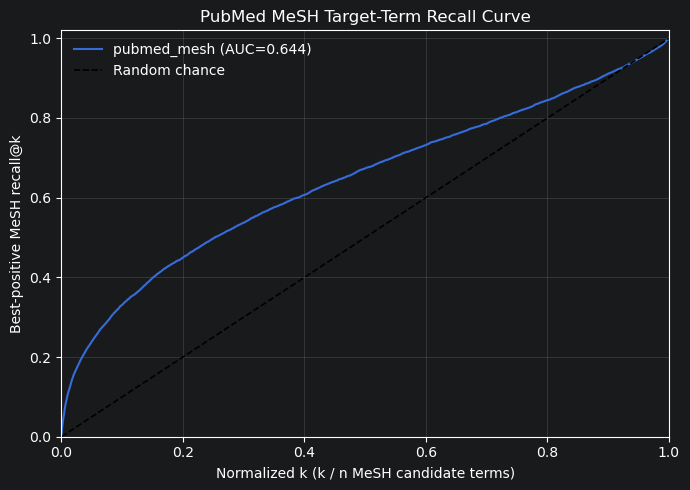

In [20]:
if len(b2t_mesh_term_recall_curve_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    auc = float(b2t_mesh_term_metrics_df.loc[0, "mesh_normalized_k_recall_curve_auc"])
    ax.plot(
        b2t_mesh_term_recall_curve_df["normalized_k"],
        b2t_mesh_term_recall_curve_df["recall_at_normalized_k"],
        label=f"pubmed_mesh (AUC={auc:.3f})",
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
    ax.set_xlabel("Normalized k (k / n MeSH candidate terms)")
    ax.set_ylabel("Best-positive MeSH recall@k")
    ax.set_title("PubMed MeSH Target-Term Recall Curve")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_pubmed_mesh_normalized_recall_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No PubMed MeSH recall curve rows to plot.")


### PubMed MeSH Node-Type Term Preview

Before plotting node-type-specific recall curves, this cell prints the number of retained MeSH candidate terms in each node type and previews the first 20 terms.


In [21]:
from neurovlm.brain_to_text_metrics import mesh_descriptor_name

mesh_candidate_preview_df = load_dataset(PUBMED_B2T_DATASET).copy()
mesh_nodes_preview_df = load_dataset("pubmed_mesh_nodes").copy()

mesh_term_col = next((col for col in ["term", "title", "name", "label"] if col in mesh_candidate_preview_df.columns), None)
mesh_node_name_col = "name" if "name" in mesh_nodes_preview_df.columns else "term"
if mesh_term_col is None:
    raise KeyError(f"{PUBMED_B2T_DATASET} must contain one of term/title/name/label columns.")

mesh_node_type_by_norm = {
    normalize_term_text(row[mesh_node_name_col]): row["node_type"]
    for _, row in mesh_nodes_preview_df.iterrows()
    if pd.notna(row.get(mesh_node_name_col)) and pd.notna(row.get("node_type"))
}
mesh_candidate_preview_df["term"] = mesh_candidate_preview_df[mesh_term_col].astype(str).map(mesh_descriptor_name)
mesh_candidate_preview_df["normalized_term"] = mesh_candidate_preview_df["term"].map(normalize_term_text)
mesh_candidate_preview_df["node_type"] = mesh_candidate_preview_df["normalized_term"].map(mesh_node_type_by_norm).fillna("")
mesh_candidate_preview_df = (
    mesh_candidate_preview_df[mesh_candidate_preview_df["node_type"].isin(MESH_BRAIN_RANKABLE_NODE_TYPES)]
    .drop_duplicates("normalized_term", keep="first")
    .sort_values(["node_type", "term"])
    .reset_index(drop=True)
)
if MESH_CANDIDATE_NORMALIZED_TERMS is not None:
    mesh_candidate_preview_df = mesh_candidate_preview_df[mesh_candidate_preview_df["normalized_term"].isin(MESH_CANDIDATE_NORMALIZED_TERMS)].reset_index(drop=True)

mesh_node_type_counts_df = (
    mesh_candidate_preview_df.groupby("node_type")
    .size()
    .reindex(MESH_BRAIN_RANKABLE_NODE_TYPES)
    .rename("n_candidate_terms")
    .reset_index()
)
display(mesh_node_type_counts_df)
print(f"Total retained candidate terms across {len(MESH_BRAIN_RANKABLE_NODE_TYPES)} node types: {len(mesh_candidate_preview_df):,}")

for node_type in MESH_BRAIN_RANKABLE_NODE_TYPES:
    terms = mesh_candidate_preview_df.loc[mesh_candidate_preview_df["node_type"] == node_type, "term"].head(20).tolist()
    print(f"\n{node_type} ({len(mesh_candidate_preview_df[mesh_candidate_preview_df["node_type"] == node_type]):,} terms):")
    for term in terms:
        print(f"  - {term}")


,node_type,n_candidate_terms
0,disorder,1627.0
1,anatomical_region,417.0
2,biological_process,NaN
3,cognitive_construct,872.0


Total retained candidate terms across 4 node types: 2,916

disorder (1,627 terms):
  - ACTH-Secreting Pituitary Adenoma
  - AIDS Arteritis, Central Nervous System
  - AIDS Dementia Complex
  - Abdomen, Acute
  - Abducens Nerve Diseases
  - Abducens Nerve Injury
  - Abnormal Karyotype
  - Abscess
  - Acantholysis
  - Accelerated Idioventricular Rhythm
  - Accessory Atrioventricular Bundle
  - Accessory Nerve Diseases
  - Accessory Nerve Injuries
  - Acrocallosal Syndrome
  - Acrodynia
  - Acromegaly
  - Acute Disease
  - Acute Febrile Encephalopathy
  - Acute-Phase Reaction
  - Adams-Stokes Syndrome

anatomical_region (417 terms):
  - Abducens Nerve
  - Abducens Nucleus
  - Accessory Nerve
  - Adrenergic Fibers
  - Adrenergic Neurons
  - Afferent Pathways
  - Amacrine Cells
  - Amygdala
  - Anterior Commissure, Brain
  - Anterior Horn Cells
  - Anterior Hypothalamic Nucleus
  - Anterior Thalamic Nuclei
  - Antilymphocyte Serum
  - Aortic Bodies
  - Arcuate Nucleus of Hypothalamus
  - Ar

### PubMed MeSH Paper Examples

This cell prints three PubMed evaluation papers with their title, reference text, and retained MeSH target terms. It also writes the same rows to CSV for easier inspection.


In [22]:
mesh_annotations_preview = load_dataset("pubmed_mesh_annotations")
mesh_norm_to_node_type = dict(zip(mesh_candidate_preview_df["normalized_term"], mesh_candidate_preview_df["node_type"]))

mesh_example_rows = []
for d in pubmed_eval:
    retained_terms_by_type = {node_type: [] for node_type in MESH_BRAIN_RANKABLE_NODE_TYPES}
    for term in mesh_annotations_preview.get(str(d["pmid"]), []):
        base = mesh_descriptor_name(term)
        norm = normalize_term_text(base)
        node_type = mesh_norm_to_node_type.get(norm)
        if node_type in retained_terms_by_type and base not in retained_terms_by_type[node_type]:
            retained_terms_by_type[node_type].append(base)
    retained_terms = [
        term
        for node_type in MESH_BRAIN_RANKABLE_NODE_TYPES
        for term in retained_terms_by_type[node_type]
    ]
    if retained_terms:
        mesh_example_rows.append({
            "pmid": str(d["pmid"]),
            "title": str(d.get("short_gt", "")),
            "abstract_or_summary": str(d.get("long_gt", "")),
            "mesh_terms": "; ".join(retained_terms),
            **{f"mesh_terms_{node_type}": "; ".join(retained_terms_by_type[node_type]) for node_type in MESH_BRAIN_RANKABLE_NODE_TYPES},
        })
    if len(mesh_example_rows) >= 3:
        break

mesh_paper_examples_df = pd.DataFrame(mesh_example_rows)
mesh_paper_examples_path = OUTPUT_DIR / "b2t_pubmed_mesh_paper_examples.csv"
mesh_paper_examples_df.to_csv(mesh_paper_examples_path, index=False)
display(mesh_paper_examples_df.drop(columns=["abstract_or_summary"]))
print(f"Saved PubMed MeSH paper examples to {mesh_paper_examples_path}")

for _, row in mesh_paper_examples_df.iterrows():
    print("\n" + "=" * 100)
    print(f"PMID: {row["pmid"]}")
    print(f"Title: {row["title"]}")
    print("\nAbstract/Summary:")
    print(row["abstract_or_summary"])
    print("\nRetained MeSH target terms:")
    for node_type in MESH_BRAIN_RANKABLE_NODE_TYPES:
        terms = row.get(f"mesh_terms_{node_type}", "")
        print(f"  {node_type}: {terms if terms else "None"}")


,pmid,title,mesh_terms,mesh_terms_disorder,mesh_terms_anatomical_region,mesh_terms_biological_process,mesh_terms_cognitive_construct
0,8994101,Acoustic neuroma: correlations between morphol...,"Cranial Nerve Neoplasms; Hearing Loss, Central...","Cranial Nerve Neoplasms; Hearing Loss, Central...",,,Reflex
1,9065511,Environmental knowledge is subserved by separa...,Brain; Judgment; Memory; Orientation; Psychomo...,,Brain,,Judgment; Memory; Orientation; Psychomotor Per...
2,9084599,Anatomy of motor learning. I. Frontal cortex a...,Prefrontal Cortex; Attention; Learning; Psycho...,,Prefrontal Cortex,,Attention; Learning; Psychomotor Performance


Saved PubMed MeSH paper examples to docs/03_evaluation/outputs/b2t_pubmed_mesh_paper_examples.csv

PMID: 8994101
Title: Acoustic neuroma: correlations between morphology and otoneurological manifestations.

Abstract/Summary:
Acoustic neuromas, benign tumors of the auditory nerve, exhibit correlations between their morphology and otoneurological manifestations. The size and site of origin of these tumors influence clinical presentation, with patients having lateral neuromas typically experiencing early subjective hearing loss due to smaller tumors often confined to the internal auditory canal. In contrast, medial neuromas tend to be larger and may grow without causing significant audiological symptoms, often preserving normal hearing function. The sensitivity of the stapedial reflex test is higher for lateral neuromas, while vestibular tests indicate a higher frequency of central vestibular involvement in larger tumors. The combination of brainstem auditory evoked potentials and vestibu

### PubMed MeSH Node-Type Recall Curves

These plots repeat the PubMed MeSH target-term ranking separately for each brain-rankable MeSH node type. For a given node type, both the target terms and the ranked candidate corpus are restricted to that node type. For example, the anatomical-region curve only counts anatomical-region MeSH annotations as targets and ranks the brain embedding against anatomical-region MeSH candidates. Each curve reports all-target fractional recall within that node type.


In [23]:
from neurovlm.brain_to_text_metrics import run_pubmed_mesh_node_type_rankings

b2t_mesh_node_type_metrics_df, b2t_mesh_node_type_recall_curve_df, b2t_mesh_node_type_examples_df = run_pubmed_mesh_node_type_rankings(
    nvlm=nvlm,
    pubmed_eval=pubmed_eval,
    pubmed_b2t_dataset=PUBMED_B2T_DATASET,
    mesh_node_types=MESH_BRAIN_RANKABLE_NODE_TYPES,
    b2t_term_example_top_k=B2T_TERM_EXAMPLE_TOP_K,
    output_dir=OUTPUT_DIR,
    run_pubmed=RUN_PUBMED,
    mesh_candidate_normalized_terms=MESH_CANDIDATE_NORMALIZED_TERMS,
)

if len(b2t_mesh_node_type_metrics_df):
    mesh_node_type_summary_cols = [
        "node_type",
        "n_queries",
        "n_candidates",
        "combined_candidate_terms",
        "mesh_normalized_k_recall_curve_auc",
        "mesh_recall@1",
        "mesh_recall@5",
        "mesh_recall@10",
        "mesh_recall@50",
        "n_target_terms",
        "mean_target_terms_per_query",
        "mesh_median_target_term_rank",
        "mesh_median_query_mean_target_term_rank",
        "mesh_median_query_worst_target_term_rank",
    ]
    display(b2t_mesh_node_type_metrics_df.reindex(columns=mesh_node_type_summary_cols).round(3))
    total_candidates = int(b2t_mesh_node_type_metrics_df["combined_candidate_terms"].dropna().max())
    print(f"Combined candidate terms across {len(MESH_BRAIN_RANKABLE_NODE_TYPES)} MeSH node types: {total_candidates:,}")
else:
    print("No PubMed MeSH node-type metrics were computed.")


Loaded PubMed MeSH annotations for 1,231,613 PMIDs


,node_type,n_queries,n_candidates,combined_candidate_terms,mesh_normalized_k_recall_curve_auc,mesh_recall@1,mesh_recall@5,mesh_recall@10,mesh_recall@50,n_target_terms,mean_target_terms_per_query,mesh_median_target_term_rank,mesh_median_query_mean_target_term_rank,mesh_median_query_worst_target_term_rank
0,disorder,930,1627,2916,0.644,0.004,0.018,0.033,0.122,1297,1.395,493.0,503.0,600.5
1,anatomical_region,2338,417,2916,0.639,0.038,0.130,0.186,0.349,4528,1.937,117.5,137.5,205.5
2,biological_process,0,0,2916,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
3,cognitive_construct,1984,872,2916,0.650,0.014,0.048,0.087,0.237,5899,2.973,226.0,280.0,512.0


Combined candidate terms across 4 MeSH node types: 2,916


### PubMed MeSH Node-Type Visualization

Each curve uses a node-type-specific candidate set and node-type-specific target terms. The legend reports the number of candidate MeSH terms retained for that node type and the all-target normalized recall-curve AUC.


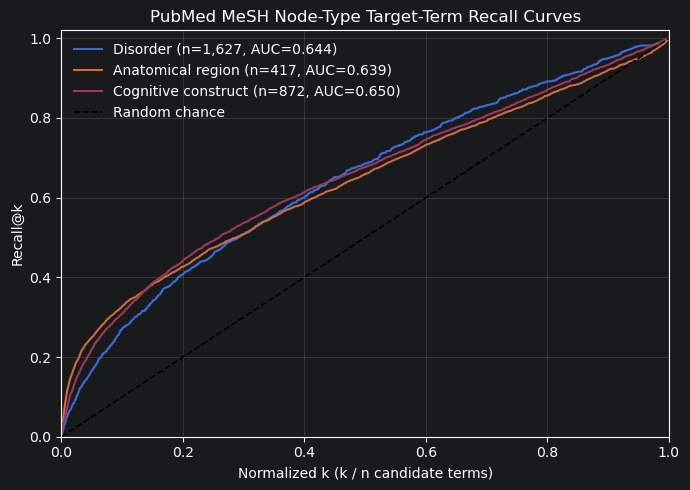

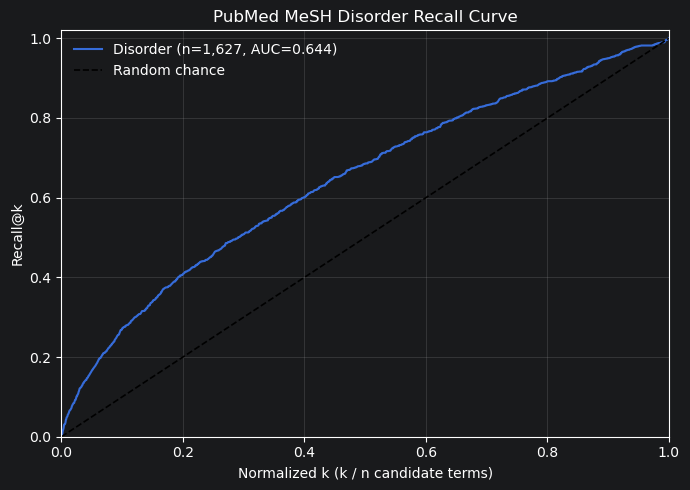

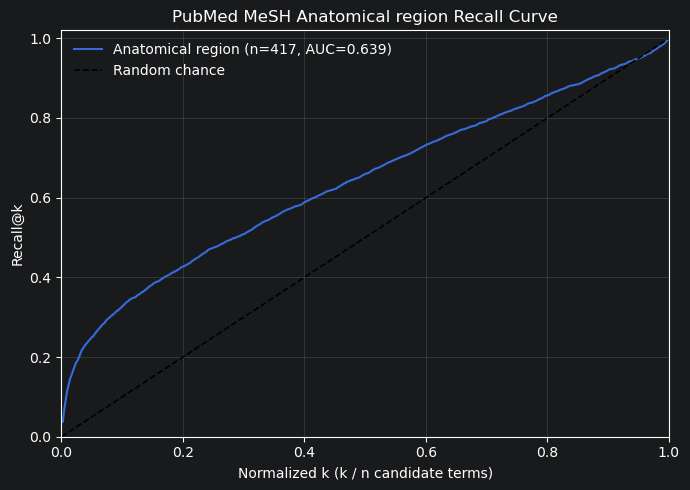

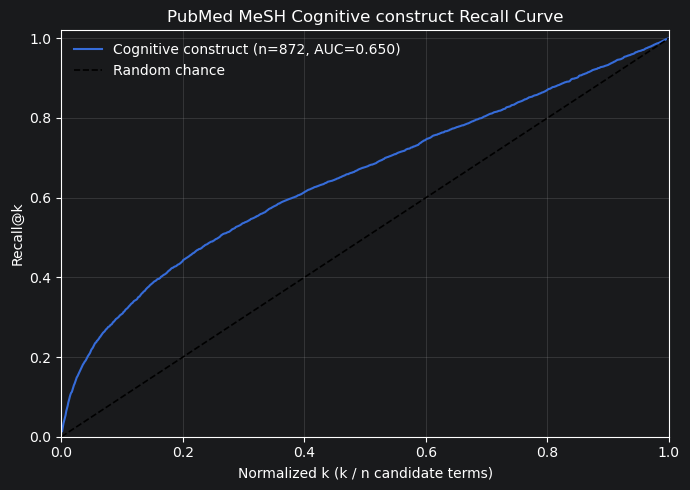

In [24]:
if len(b2t_mesh_node_type_recall_curve_df):
    node_type_labels = {
        "disorder": "Disorder",
        "anatomical_region": "Anatomical region",
        "biological_process": "Biological process",
        "cognitive_construct": "Cognitive construct",
    }
    metrics_by_type = b2t_mesh_node_type_metrics_df.set_index("node_type")

    fig, ax = plt.subplots(figsize=(7, 5))
    for node_type in MESH_BRAIN_RANKABLE_NODE_TYPES:
        sub = b2t_mesh_node_type_recall_curve_df[b2t_mesh_node_type_recall_curve_df["node_type"] == node_type]
        if sub.empty or node_type not in metrics_by_type.index:
            continue
        metrics_row = metrics_by_type.loc[node_type]
        auc = float(metrics_row["mesh_normalized_k_recall_curve_auc"])
        n_candidates = int(metrics_row["n_candidates"])
        label = f"{node_type_labels.get(node_type, node_type)} (n={n_candidates:,}, AUC={auc:.3f})"
        ax.plot(sub["normalized_k"], sub["recall_at_normalized_k"], label=label)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
    ax.set_xlabel("Normalized k (k / n candidate terms)")
    ax.set_ylabel("Recall@k")
    ax.set_title("PubMed MeSH Node-Type Target-Term Recall Curves")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_pubmed_mesh_node_type_normalized_recall_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    for node_type in MESH_BRAIN_RANKABLE_NODE_TYPES:
        sub = b2t_mesh_node_type_recall_curve_df[b2t_mesh_node_type_recall_curve_df["node_type"] == node_type]
        if sub.empty or node_type not in metrics_by_type.index:
            continue
        metrics_row = metrics_by_type.loc[node_type]
        auc = float(metrics_row["mesh_normalized_k_recall_curve_auc"])
        n_candidates = int(metrics_row["n_candidates"])
        display_name = node_type_labels.get(node_type, node_type)
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(sub["normalized_k"], sub["recall_at_normalized_k"], label=f"{display_name} (n={n_candidates:,}, AUC={auc:.3f})")
        ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
        ax.set_xlabel("Normalized k (k / n candidate terms)")
        ax.set_ylabel("Recall@k")
        ax.set_title(f"PubMed MeSH {display_name} Recall Curve")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.grid(alpha=0.25)
        ax.legend(frameon=False)
        fig.tight_layout()
        plt.savefig(OUTPUT_DIR / f"b2t_pubmed_mesh_{node_type}_normalized_recall_curve.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("No PubMed MeSH node-type recall curve rows to plot.")


## Generated Text Evaluation

This optional section compares LLM-generated text against the ground-truth text. It is disabled by default with `RUN_GENERATED_TEXT = False` because it is much slower than the retrieval metrics.

Metrics in this section, when enabled:

- `bert_p`, `bert_r`, `bert_f1`: BERTScore precision, recall, and F1 between generated text and ground truth. These check token-level contextual semantic overlap.
- `sem_sim`: MiniLM sentence-embedding similarity between generated text and ground truth.
- `nvlm_sim`: cosine similarity between the generated text embedding and the brain query in NeuroVLM's shared latent space.
- `generated_text_normalized_k_recall_curve_auc`: embeds each generated text and asks how early it retrieves its source brain map within the dataset/mode group, summarized as area under Recall@k over normalized `k / n`.
- Network label accuracy metrics: for Networks, these check whether the generated text names the correct network label by alias matching or semantic matching.

Because generation depends on the LLM as well as the retrieval results, this section should be interpreted alongside the paper-level retrieval and network term-ranking metrics.


In [25]:
if RUN_GENERATED_TEXT:
    b2t_frames = []

    if RUN_NETWORKS:
        records = []
        for net_name, d in tqdm(networks_data.items(), desc="Networks B2T"):
            records.extend(run_b2t(net_name, d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_GENERAL, LONG_PROMPT))
        b2t_net_df = add_network_label_accuracy(pd.DataFrame(records))
        b2t_net_df["dataset"] = "networks"
        b2t_frames.append(b2t_net_df)

    if RUN_PUBMED:
        records = []
        for d in tqdm(pubmed_eval, desc="PubMed B2T"):
            records.extend(run_b2t(str(d["pmid"]), d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_PUBMED, LONG_PROMPT, datasets=[PUBMED_B2T_DATASET]))
        b2t_pubmed_df = pd.DataFrame(records)
        b2t_pubmed_df["dataset"] = "pubmed"
        b2t_frames.append(b2t_pubmed_df)

    if RUN_NEUROVAULT:
        records = []
        for d in tqdm(neurovault_eval, desc="NeuroVault B2T"):
            records.extend(run_b2t(str(d["doi"]), d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_GENERAL, LONG_PROMPT))
        b2t_nv_df = pd.DataFrame(records)
        b2t_nv_df["dataset"] = "neurovault"
        b2t_frames.append(b2t_nv_df)

    b2t_all = pd.concat(b2t_frames, ignore_index=True)
    b2t_all.to_csv(OUTPUT_DIR / "brain_to_text_metrics_v2.csv", index=False)
    b2t_all.head()
else:
    print("Skipping generated text evaluation because RUN_GENERATED_TEXT = False.")
    b2t_all = pd.DataFrame()


Skipping generated text evaluation because RUN_GENERATED_TEXT = False.


### Generated Text Summary Tables

These tables summarize optional LLM-generation metrics. `bert_f1` measures contextual text overlap with the reference, `sem_sim` measures MiniLM sentence similarity, `nvlm_sim` measures similarity in NeuroVLM's shared latent space, and `generated_text_normalized_k_recall_curve_auc` measures whether generated texts retrieve their source brain maps early across the full normalized `k / n` retrieval curve within each dataset/mode group.


In [26]:
from neurovlm.brain_to_text_metrics import generated_text_metric_summary

if RUN_GENERATED_TEXT and len(b2t_all):
    summary, generated_text_recall_auc_df, generated_text_recall_curve_df, label_summary = generated_text_metric_summary(
        nvlm=nvlm,
        b2t_all=b2t_all,
        networks_data=networks_data,
        pubmed_eval=pubmed_eval,
        neurovault_eval=neurovault_eval,
        output_dir=OUTPUT_DIR,
    )
    display(summary)
    display(generated_text_recall_auc_df.round(3))
    if len(label_summary):
        display(label_summary)
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


### Generated Text Normalized Recall Curves

This plot shows the full generated-text retrieval curve. Each generated output is embedded back into the NeuroVLM text space and ranked against the brain maps in the same dataset/mode group; the AUC summarizes Recall@k over normalized `k / n`, so groups with different sizes are comparable.


In [27]:
if RUN_GENERATED_TEXT and len(b2t_all) and len(generated_text_recall_curve_df):
    fig, ax = plt.subplots(figsize=(8, 5))
    for (dataset, mode), curve_df in generated_text_recall_curve_df.groupby(["dataset", "mode"]):
        auc_row = generated_text_recall_auc_df[
            (generated_text_recall_auc_df["dataset"] == dataset) &
            (generated_text_recall_auc_df["mode"] == mode)
        ]
        auc = float(auc_row["generated_text_normalized_k_recall_curve_auc"].iloc[0]) if len(auc_row) else np.nan
        ax.plot(
            curve_df["normalized_k"],
            curve_df["recall_at_normalized_k"],
            label=f"{dataset} {mode} (AUC={auc:.3f})",
        )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
    ax.set_xlabel("Normalized k (k / n brain maps)")
    ax.set_ylabel("Generated-text recall@k")
    ax.set_title("Generated Text Normalized Brain Retrieval Curves")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_generated_text_normalized_recall_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping generated-text normalized recall curve because RUN_GENERATED_TEXT = False or no curve rows are available.")


Skipping generated-text normalized recall curve because RUN_GENERATED_TEXT = False or no curve rows are available.


### Generated Text Metric Distributions

These plots show the distribution of generated-text scores by dataset and output mode, making it easier to see whether an average is driven by consistent behavior or a few strong/weak examples.


In [28]:
if RUN_GENERATED_TEXT and len(b2t_all):
    plot_df = b2t_all.copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metric_specs = [("nvlm_sim", "NeuroVLM latent similarity"), ("bert_f1", "BERTScore F1"), ("sem_sim", "Sentence semantic similarity")]
    for ax, (metric, title) in zip(axes, metric_specs):
        groups = [g[metric].dropna().values for _, g in plot_df.groupby("dataset")]
        labels = [k for k, _ in plot_df.groupby("dataset")]
        ax.boxplot(groups, labels=labels, showmeans=True)
        ax.set_title(title)
        ax.set_ylim(min(-0.05, np.nanmin(plot_df[metric]) - 0.05), min(1.05, np.nanmax(plot_df[metric]) + 0.1))
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="x", rotation=15)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_metric_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


### NeuroVLM Similarity Scale Check

This visualization compares matched generated-text/brain similarities with random pairings. It gives `nvlm_sim` an empirical baseline, which is more useful than reading cosine similarity as if only values near 1.0 were meaningful.


In [29]:
from neurovlm.brain_to_text_metrics import generated_text_pair_baseline

if RUN_GENERATED_TEXT and len(b2t_all):
    baseline_df = generated_text_pair_baseline(
        nvlm=nvlm,
        b2t_all=b2t_all,
        networks_data=networks_data,
        pubmed_eval=pubmed_eval,
        neurovault_eval=neurovault_eval,
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    if len(baseline_df):
        matched = baseline_df[baseline_df["pair"] == "matched"]["score"]
        random_pairs = baseline_df[baseline_df["pair"] == "random/off-diagonal"]["score"]
        bins = np.linspace(min(baseline_df["score"].min(), 0), baseline_df["score"].max(), 24)
        ax.hist(random_pairs, bins=bins, alpha=0.55, label="random/off-diagonal pairs", color="lightgray", edgecolor="white")
        ax.hist(matched, bins=bins, alpha=0.75, label="matched generated text", color="steelblue", edgecolor="white")
        for x, lab, color in [(matched.median(), "matched median", "steelblue"), (random_pairs.median(), "random median", "gray")]:
            ax.axvline(x, color=color, linestyle="--", linewidth=1)
            ax.text(x, ax.get_ylim()[1] * 0.92, f"{lab}\n{x:.3f}", ha="center", va="top", fontsize=8)
    else:
        vals = b2t_all["nvlm_sim"].dropna()
        ax.hist(vals, bins=min(20, max(5, len(vals) // 2)), alpha=0.75, color="steelblue", edgecolor="white")
        ax.text(0.5, 0.9, "Need at least two samples per group for random-pair baseline", transform=ax.transAxes, ha="center")
    ax.set_title("How to read nvlm_sim: matched text versus random pairs")
    ax.set_xlabel("NeuroVLM latent cosine similarity")
    ax.set_ylabel("Pairs")
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_nvlm_sim_scale.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


### Network Label Accuracy Visualization

For generated Network outputs, this plot and confusion matrix show whether the generated text names the correct canonical network label, using alias matching first and semantic matching as a fallback.


In [30]:
if RUN_GENERATED_TEXT and len(b2t_all):
    if "network_label_correct" in b2t_all.columns:
        net = b2t_all[b2t_all["dataset"] == "networks"].copy()
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        acc = net.groupby("mode")["network_label_correct"].mean()
        axes[0].bar(acc.index, acc.values, color=["#4c78a8", "#72b7b2"])
        axes[0].set_ylim(0, 1)
        axes[0].set_ylabel("Accuracy")
        axes[0].set_title("Network label accuracy")
        axes[0].grid(axis="y", alpha=0.25)

        cm = pd.crosstab(net["true_network_key"], net["pred_network_key"], normalize="index")
        im = axes[1].imshow(cm.values, vmin=0, vmax=1, cmap="Blues")
        axes[1].set_xticks(range(len(cm.columns)), cm.columns, rotation=45, ha="right")
        axes[1].set_yticks(range(len(cm.index)), cm.index)
        axes[1].set_title("Predicted network label by true label")
        fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        fig.tight_layout()
        plt.savefig(OUTPUT_DIR / "b2t_network_label_accuracy.png", dpi=150, bbox_inches="tight")
        plt.show()

        display(net[["name", "mode", "true_network_key", "pred_network_key", "network_label_correct", "label_match_method", "generated"]])
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.
